### Import Dependencies

In [ ]:
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data.dataset import Dataset
from transformers import (
    TrainingArguments, Trainer, BertTokenizer,
    BertPreTrainedModel, BertConfig,
    EarlyStoppingCallback, BertModel
)
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import datasets

import evaluate
import random
from collections import Counter

### Main Code

Original minority samples: 4874
Original majority samples: 21126
Generated 24370 augmented samples
New dataset size: 50370
New minority ratio: 0.581

Dataset splits:
Train: 36266 samples
Eval: 4030 samples
Test: 10074 samples

Importance class weights: tensor([1.0918, 0.9280])
Sentiment class weights: tensor([1.2052, 1.0461, 0.8459])

Class distribution in training set:
Importance: Counter({1: 21055, 0: 15211})
Sentiment: Counter({2: 16896, 1: 11047, 0: 8323})


Map:   0%|          | 0/36266 [00:00<?, ? examples/s]

Map:   0%|          | 0/10074 [00:00<?, ? examples/s]

Map:   0%|          | 0/4030 [00:00<?, ? examples/s]

Some weights of ImprovedMultiTaskFinBert were not initialized from the model checkpoint at yiyanghkust/finbert-pretrain and are newly initialized: ['finBert.embeddings.LayerNorm.bias', 'finBert.embeddings.LayerNorm.weight', 'finBert.embeddings.position_embeddings.weight', 'finBert.embeddings.token_type_embeddings.weight', 'finBert.embeddings.word_embeddings.weight', 'finBert.encoder.layer.0.attention.output.LayerNorm.bias', 'finBert.encoder.layer.0.attention.output.LayerNorm.weight', 'finBert.encoder.layer.0.attention.output.dense.bias', 'finBert.encoder.layer.0.attention.output.dense.weight', 'finBert.encoder.layer.0.attention.self.key.bias', 'finBert.encoder.layer.0.attention.self.key.weight', 'finBert.encoder.layer.0.attention.self.query.bias', 'finBert.encoder.layer.0.attention.self.query.weight', 'finBert.encoder.layer.0.attention.self.value.bias', 'finBert.encoder.layer.0.attention.self.value.weight', 'finBert.encoder.layer.0.intermediate.dense.bias', 'finBert.encoder.layer.0.int


TRAINING CONFIGURATION
Early stopping patience: 2 epochs (VERY AGGRESSIVE)
Early stopping threshold: 0.001
Monitoring: VALIDATION LOSS (not F1)
Max epochs: 20 (will likely stop around epoch 6-8)
Total trainable parameters: 45,028,101



Epoch,Training Loss,Validation Loss,F1 Sent Weighted,F1 Sent Macro,F1 Imp Weighted,F1 Imp Macro,F1 Avg
1,0.916800,0.768264,0.434957,0.362466,0.894942,0.893897,0.628182
2,0.704500,0.619829,0.624784,0.599212,0.929969,0.928841,0.764027
3,0.591500,0.490416,0.698706,0.693380,0.959942,0.959044,0.826212
4,0.519900,0.467366,0.720367,0.713808,0.962625,0.961736,0.837772
5,0.473500,0.423639,0.746366,0.744772,0.968555,0.967794,0.856283
6,0.434300,0.407210,0.748979,0.745637,0.974482,0.973844,0.859741
7,0.402400,0.386777,0.773794,0.773542,0.971784,0.971114,0.872328
8,0.381200,0.378339,0.782346,0.784405,0.976926,0.976313,0.880359
9,0.358600,0.361037,0.786862,0.788191,0.979670,0.979146,0.883669
10,0.332500,0.391632,0.787964,0.787897,0.978931,0.978392,0.883144


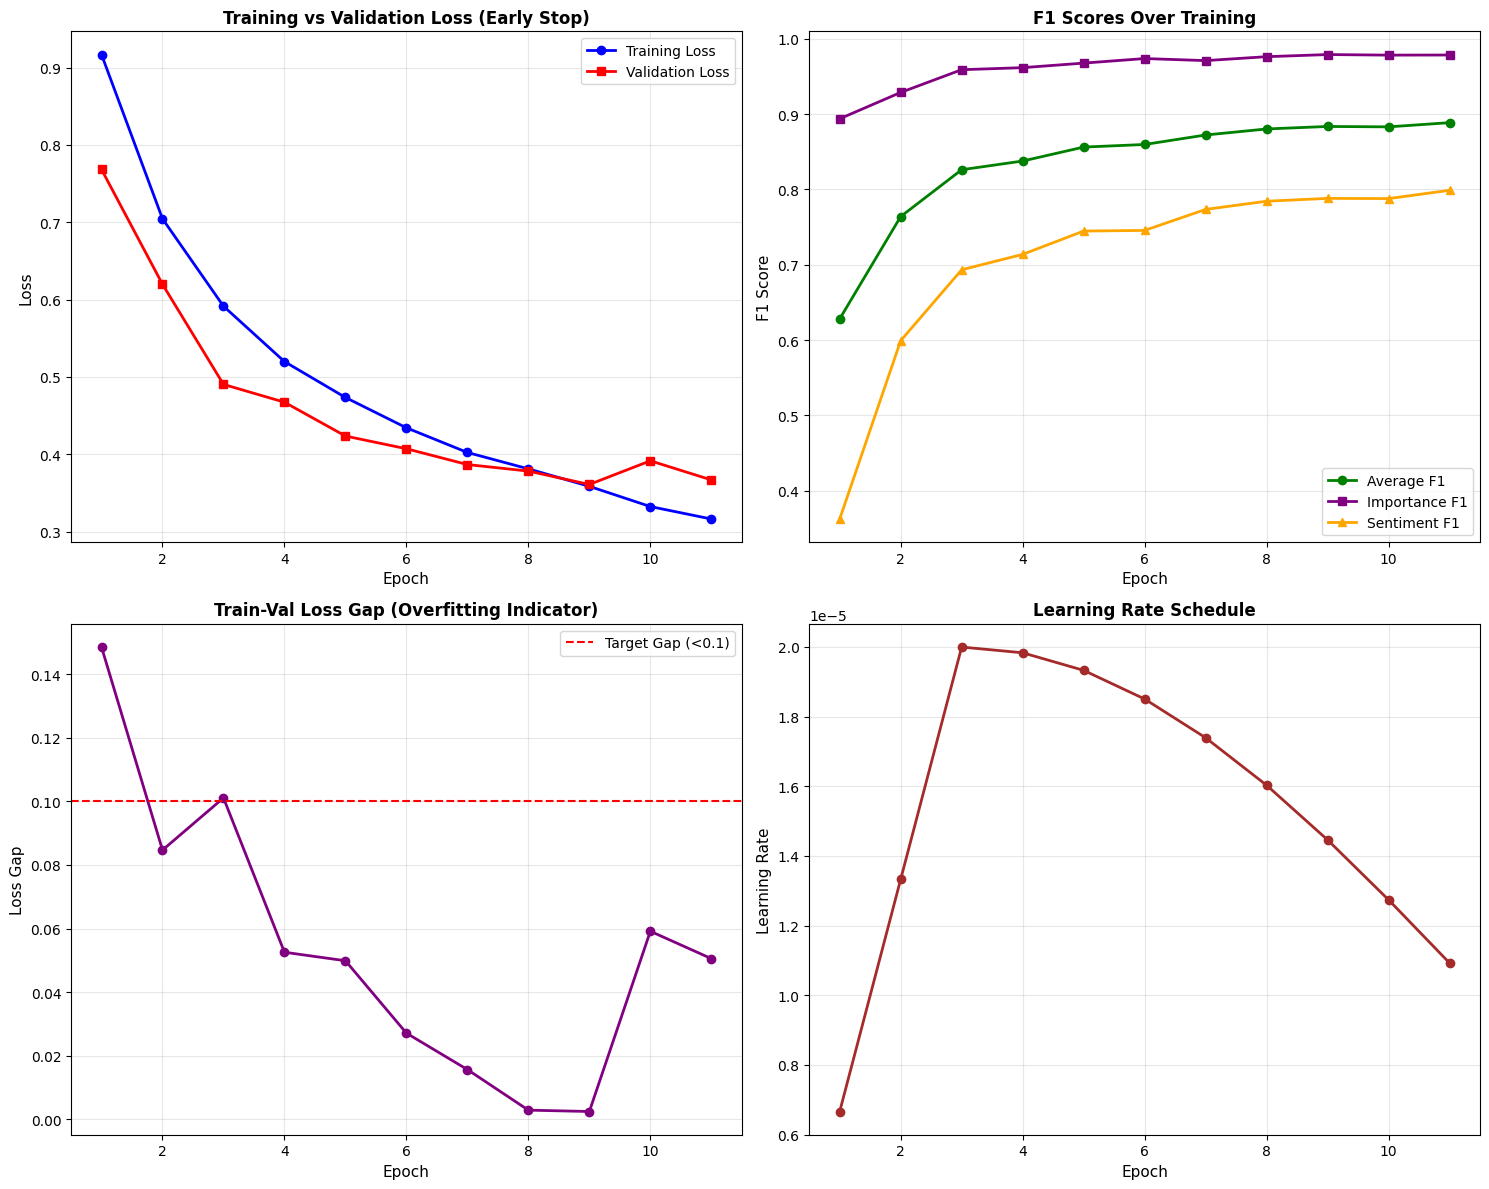


Final Training Loss: 0.3164
Final Validation Loss: 0.3669
Loss Gap: 0.0505
Best F1 Average: 0.8887
Best Importance F1: 0.9791
Best Sentiment F1: 0.7989
Training stopped at epoch: 11

VALIDATION SET EVALUATION


eval_loss: 0.3610
eval_f1_sent_weighted: 0.7869
eval_f1_sent_macro: 0.7882
eval_f1_imp_weighted: 0.9797
eval_f1_imp_macro: 0.9791
eval_f1_avg: 0.8837
eval_runtime: 3.8103
eval_samples_per_second: 1057.6670
eval_steps_per_second: 66.1370
epoch: 11.0000

TEST SET EVALUATION
eval_loss: 0.3601
eval_f1_sent_weighted: 0.7928
eval_f1_sent_macro: 0.7933
eval_f1_imp_weighted: 0.9763
eval_f1_imp_macro: 0.9757
eval_f1_avg: 0.8845
eval_runtime: 12.2762
eval_samples_per_second: 820.6120
eval_steps_per_second: 51.3190
epoch: 11.0000

SENTIMENT CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

    Negative     0.8461    0.8018    0.8234      2276
     Neutral     0.7592    0.7432    0.7511      3088
    Positive     0.7902    0.8210    0.8053      4710

    accuracy                         0.7928     10074
   macro avg     0.7985    0.7887    0.7933     10074
weighted avg     0.7933    0.7928    0.7928     10074


IMPORTANCE CLASSIFICATION REPORT (TEST SET)
     

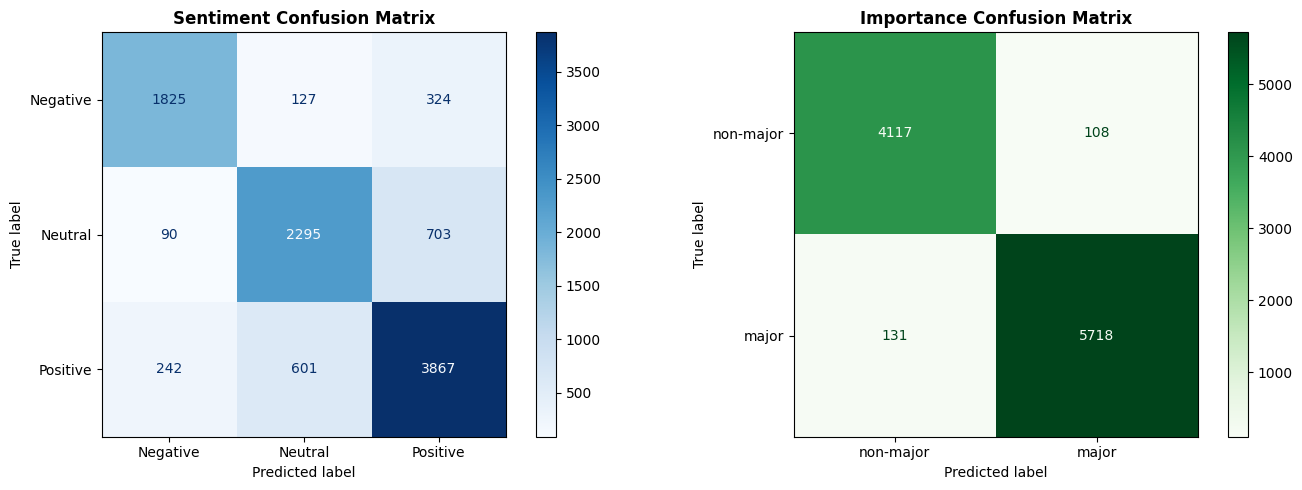


PER-CLASS ANALYSIS
non-major: 4225 samples, accuracy: 0.9744
major: 5849 samples, accuracy: 0.9776

Sentiment classes:
Negative: 2276 samples, accuracy: 0.8018
Neutral: 3088 samples, accuracy: 0.7432
Positive: 4710 samples, accuracy: 0.8210

MODEL SAVED TO: /content/drive/MyDrive/NLP_MajorMoveID/improved_model


In [ ]:
def synonym_replacement(text, n=2):
    """Enhanced synonym replacement with financial terms"""
    words = text.split()
    if len(words) < 3:
        return text

    synonyms = {
        'increase': ['rise', 'growth', 'gain', 'surge', 'jump', 'climb'],
        'decrease': ['decline', 'fall', 'drop', 'plunge', 'tumble', 'slide'],
        'profit': ['earnings', 'income', 'revenue', 'gains', 'returns'],
        'loss': ['deficit', 'shortfall', 'decline', 'losses'],
        'company': ['firm', 'corporation', 'business', 'enterprise'],
        'stock': ['shares', 'equity', 'securities', 'holdings'],
        'market': ['trading', 'exchange', 'marketplace'],
        'good': ['positive', 'strong', 'favorable', 'solid', 'robust'],
        'bad': ['negative', 'weak', 'unfavorable', 'poor'],
        'high': ['elevated', 'increased', 'higher', 'raised'],
        'low': ['reduced', 'decreased', 'lower', 'diminished'],
        'announce': ['report', 'reveal', 'disclose', 'state'],
        'beat': ['exceed', 'surpass', 'outperform'],
        'miss': ['fall short', 'underperform'],
        'revenue': ['sales', 'income', 'turnover'],
        'quarter': ['Q1', 'Q2', 'Q3', 'Q4', 'period'],
    }

    new_words = words.copy()
    random_word_list = list(set([word.lower() for word in words]))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        if random_word in synonyms and num_replaced < n:
            synonym = random.choice(synonyms[random_word])
            for i, word in enumerate(new_words):
                if word.lower() == random_word:
                    new_words[i] = synonym
                    num_replaced += 1
                    break

    return ' '.join(new_words)

def random_insertion(text, n=1):
    """Insert random words from the text"""
    words = text.split()
    if len(words) < 2:
        return text

    new_words = words.copy()
    for _ in range(n):
        random_word = random.choice(words)
        random_idx = random.randint(0, len(new_words))
        new_words.insert(random_idx, random_word)

    return ' '.join(new_words)

def random_swap(text, n=2):
    """Randomly swap words"""
    words = text.split()
    if len(words) < 2:
        return text

    new_words = words.copy()
    for _ in range(n):
        if len(new_words) >= 2:
            idx1, idx2 = random.sample(range(len(new_words)), 2)
            new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]

    return ' '.join(new_words)

def random_deletion(text, p=0.1):
    """Randomly delete words with probability p"""
    words = text.split()
    if len(words) == 1:
        return text

    new_words = []
    for word in words:
        if random.uniform(0, 1) > p:
            new_words.append(word)

    if len(new_words) == 0:
        return random.choice(words)

    return ' '.join(new_words)

def eda_augment(text):
    """Apply random EDA technique"""
    aug_type = random.choice(['synonym', 'insert', 'swap', 'delete'])
    if aug_type == 'synonym':
        return synonym_replacement(text, n=2)
    elif aug_type == 'insert':
        return random_insertion(text, n=1)
    elif aug_type == 'swap':
        return random_swap(text, n=2)
    else:
        return random_deletion(text, p=0.1)

def augment_minority_class_aggressive(df, text_col='headline', label_col='importance',
                                      minority_class='major', multiplier=5):
    """More aggressive augmentation for minority class"""
    minority_samples = df[df[label_col] == minority_class].copy()
    majority_samples = df[df[label_col] != minority_class].copy()

    print(f"Original minority samples: {len(minority_samples)}")
    print(f"Original majority samples: {len(majority_samples)}")

    augmented_data = []
    for _ in range(multiplier):
        for idx, row in minority_samples.iterrows():
            new_row = row.copy()
            new_row[text_col] = eda_augment(row[text_col])
            augmented_data.append(new_row)

    augmented_df = pd.DataFrame(augmented_data)
    df_balanced = pd.concat([df, augmented_df], ignore_index=True)

    print(f"Generated {len(augmented_df)} augmented samples")
    print(f"New dataset size: {len(df_balanced)}")
    print(f"New minority ratio: {len(df_balanced[df_balanced[label_col] == minority_class]) / len(df_balanced):.3f}")

    return df_balanced

df_path = "/content/drive/MyDrive/NLP_MajorMoveID/data/raw/complete_labeled_dataset.csv"
df = pd.read_csv(df_path)

df.drop(columns=["importance", "binary_label", "confidence", "source"], inplace=True)
df = df.rename(columns={"label": "sentiment", "label_name": "importance"})

df = augment_minority_class_aggressive(df, text_col='headline', label_col='importance',
                                       minority_class='major', multiplier=5)

sentiment_classes = ["Negative", "Neutral", "Positive"]
importance_classes = ["non-major", "major"]

multitask_features = datasets.Features({
    "headline": datasets.Value("string"),
    "sentiment": datasets.ClassLabel(names=sentiment_classes),
    "importance": datasets.ClassLabel(names=importance_classes),
})

ds = datasets.Dataset.from_pandas(df, features=multitask_features)

ds = ds.train_test_split(test_size=0.2, seed=42, stratify_by_column="importance")
train_val_ds = ds["train"].train_test_split(test_size=0.1, seed=42, stratify_by_column="importance")

ds = datasets.DatasetDict({
    "train": train_val_ds["train"],
    "test": ds["test"],
    "eval": train_val_ds["test"]
})

print("\nDataset splits:")
print(f"Train: {len(ds['train'])} samples")
print(f"Eval: {len(ds['eval'])} samples")
print(f"Test: {len(ds['test'])} samples")

importance_labels = [item['importance'] for item in ds['train']]
importance_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=importance_labels
)
importance_class_weights = np.sqrt(importance_class_weights)
importance_class_weights = torch.tensor(importance_class_weights, dtype=torch.float32)

sentiment_labels = [item['sentiment'] for item in ds['train']]
sentiment_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1, 2]), y=sentiment_labels
)
sentiment_class_weights = np.sqrt(sentiment_class_weights)
sentiment_class_weights = torch.tensor(sentiment_class_weights, dtype=torch.float32)

print(f"\nImportance class weights: {importance_class_weights}")
print(f"Sentiment class weights: {sentiment_class_weights}")

print("\nClass distribution in training set:")
print("Importance:", Counter(importance_labels))
print("Sentiment:", Counter(sentiment_labels))

MAX_SEQUENCE_LENGTH = 512
model_name = "yiyanghkust/finbert-pretrain"
tokenizer = BertTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["headline"], truncation=True, padding=False, max_length=MAX_SEQUENCE_LENGTH)

ds = ds.map(tokenize_fn, batched=True)
ds = ds.remove_columns(['headline'])

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        num_classes = inputs.size(-1)
        if self.label_smoothing > 0:
            targets_one_hot = F.one_hot(targets, num_classes).float()
            targets_one_hot = targets_one_hot * (1 - self.label_smoothing) + \
                             self.label_smoothing / num_classes

            log_probs = F.log_softmax(inputs, dim=-1)
            ce_loss = -(targets_one_hot * log_probs).sum(dim=-1)
        else:
            ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

class MultiTaskFinBert(BertPreTrainedModel):
    def __init__(self, config, importance_weights=None, sentiment_weights=None):
        super().__init__(config)
        self.num_sent_labels = getattr(config, "num_sent_labels", 3)
        self.num_imp_labels = getattr(config, "num_imp_labels", 2)

        self.finBert = BertModel(config)

        self.shared_layer = nn.Sequential(
            nn.Linear(config.hidden_size, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        self.sent_proj1 = nn.Linear(768, 512)
        self.sent_norm1 = nn.LayerNorm(512)
        self.sent_dropout1 = nn.Dropout(0.3)

        self.sent_proj2 = nn.Linear(512, 512)
        self.sent_norm2 = nn.LayerNorm(512)
        self.sent_dropout2 = nn.Dropout(0.3)

        self.sent_proj3 = nn.Linear(512, 256)
        self.sent_norm3 = nn.LayerNorm(256)
        self.sent_dropout3 = nn.Dropout(0.2)

        self.sent_out = nn.Linear(256, self.num_sent_labels)

        self.imp_proj1 = nn.Linear(768, 512)
        self.imp_norm1 = nn.LayerNorm(512)
        self.imp_dropout1 = nn.Dropout(0.3)

        self.imp_proj2 = nn.Linear(512, 256)
        self.imp_norm2 = nn.LayerNorm(256)
        self.imp_dropout2 = nn.Dropout(0.3)

        self.imp_out = nn.Linear(256, self.num_imp_labels)

        self.sentiment_loss_fn = FocalLoss(alpha=sentiment_weights, gamma=2.0, label_smoothing=0.1)
        self.importance_loss_fn = FocalLoss(alpha=importance_weights, gamma=2.5, label_smoothing=0.05)

        self.init_weights()

    def freeze_layers(self, freeze_transformer=True, unfreeze_layers=6):
        for param in self.finBert.parameters():
            param.requires_grad = not freeze_transformer

        for layer in self.finBert.encoder.layer[-unfreeze_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

        for param in self.finBert.pooler.parameters():
            param.requires_grad = True

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                sentiment=None, importance=None):
        outputs = self.finBert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled_output = outputs[1]

        shared_repr = self.shared_layer(pooled_output)

        sent_h1 = self.sent_dropout1(F.gelu(self.sent_norm1(self.sent_proj1(shared_repr))))
        sent_h2 = self.sent_dropout2(F.gelu(self.sent_norm2(self.sent_proj2(sent_h1))))
        sent_h2 = sent_h2 + sent_h1  # Residual connection
        sent_h3 = self.sent_dropout3(F.gelu(self.sent_norm3(self.sent_proj3(sent_h2))))
        logits_sent = self.sent_out(sent_h3)

        imp_h1 = self.imp_dropout1(F.gelu(self.imp_norm1(self.imp_proj1(shared_repr))))
        imp_h2 = self.imp_dropout2(F.gelu(self.imp_norm2(self.imp_proj2(imp_h1))))
        logits_imp = self.imp_out(imp_h2)

        loss = None
        if sentiment is not None and importance is not None:
            loss_sent = self.sentiment_loss_fn(logits_sent, sentiment)
            loss_imp = self.importance_loss_fn(logits_imp, importance)
            loss = 1.5 * loss_sent + 2.0 * loss_imp

        return (loss, logits_sent, logits_imp) if loss is not None else (logits_sent, logits_imp)

IMP_METRIC = evaluate.load("f1")
SENT_METRIC = evaluate.load("f1")

def compute_metrics(eval_pred):
    all_logits, all_labels = eval_pred
    sent_logits, imp_logits = all_logits
    sent_labels, imp_labels = all_labels
    sent_pred = np.argmax(sent_logits, axis=1)
    imp_pred = np.argmax(imp_logits, axis=1)

    sent_computed_metrics = SENT_METRIC.compute(predictions=sent_pred, references=sent_labels, average="weighted")
    imp_computed_metrics = IMP_METRIC.compute(predictions=imp_pred, references=imp_labels, average="weighted")
    imp_macro_f1 = IMP_METRIC.compute(predictions=imp_pred, references=imp_labels, average="macro")
    sent_macro_f1 = SENT_METRIC.compute(predictions=sent_pred, references=sent_labels, average="macro")

    return {
        "f1_sent_weighted": sent_computed_metrics["f1"],
        "f1_sent_macro": sent_macro_f1["f1"],
        "f1_imp_weighted": imp_computed_metrics["f1"],
        "f1_imp_macro": imp_macro_f1["f1"],
        "f1_avg": (sent_macro_f1["f1"] + imp_macro_f1["f1"]) / 2
    }

def data_collator(batch, padding_token_id=tokenizer.pad_token_id):
    input_ids = [item["input_ids"][:MAX_SEQUENCE_LENGTH] for item in batch]
    attention_masks = [item["attention_mask"][:MAX_SEQUENCE_LENGTH] for item in batch]
    sentiment = [item["sentiment"] for item in batch]
    importance = [item["importance"] for item in batch]

    max_len = max(len(ids) for ids in input_ids)
    input_ids = torch.tensor([ids + [padding_token_id] * (max_len - len(ids)) for ids in input_ids])
    attention_masks = torch.tensor([masks + [0] * (max_len - len(masks)) for masks in attention_masks])
    sentiment = torch.tensor(sentiment)
    importance = torch.tensor(importance)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks,
        "sentiment": sentiment,
        "importance": importance
    }

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/NLP_MajorMoveID/results_improved",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=20,
    weight_decay=0.01,
    logging_dir="/content/drive/MyDrive/NLP_MajorMoveID/logs_improved",
    label_names=['sentiment', 'importance'],
    lr_scheduler_type="cosine",
    warmup_ratio=0.15,
    logging_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    metric_for_best_model='eval_loss',
    report_to="none",
    fp16=True,
    seed=42,
    max_grad_norm=1.0,
)

early_stop_callback = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.001
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
importance_class_weights = importance_class_weights.to(device)
sentiment_class_weights = sentiment_class_weights.to(device)

model = MultiTaskFinBert.from_pretrained(
    model_name,
    importance_weights=importance_class_weights,
    sentiment_weights=sentiment_class_weights,
)

model.freeze_layers(unfreeze_layers=6)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds['eval'],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[early_stop_callback],
)

print("\n" + "="*60)
print("TRAINING CONFIGURATION")
print("="*60)
print(f"Early stopping patience: 2 epochs (VERY AGGRESSIVE)")
print(f"Early stopping threshold: 0.001")
print(f"Monitoring: VALIDATION LOSS (not F1)")
print(f"Max epochs: 20 (will likely stop around epoch 6-8)")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*60 + "\n")

trainer.train()

log_history = trainer.state.log_history

train_loss = [x['loss'] for x in log_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_f1_avg = [x['eval_f1_avg'] for x in log_history if 'eval_f1_avg' in x]
eval_f1_imp = [x['eval_f1_imp_macro'] for x in log_history if 'eval_f1_imp_macro' in x]
eval_f1_sent = [x['eval_f1_sent_macro'] for x in log_history if 'eval_f1_sent_macro' in x]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].plot(range(1, len(train_loss) + 1), train_loss, 'b-o', label='Training Loss', linewidth=2)
axes[0, 0].plot(range(1, len(eval_loss) + 1), eval_loss, 'r-s', label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Training vs Validation Loss (Early Stop)', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(1, len(eval_f1_avg) + 1), eval_f1_avg, 'g-o', label='Average F1', linewidth=2)
axes[0, 1].plot(range(1, len(eval_f1_imp) + 1), eval_f1_imp, 'purple', marker='s', label='Importance F1', linewidth=2)
axes[0, 1].plot(range(1, len(eval_f1_sent) + 1), eval_f1_sent, 'orange', marker='^', label='Sentiment F1', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('F1 Score', fontsize=11)
axes[0, 1].set_title('F1 Scores Over Training', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

loss_gap = [abs(t - e) for t, e in zip(train_loss, eval_loss)]
axes[1, 0].plot(range(1, len(loss_gap) + 1), loss_gap, 'purple', marker='o', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Loss Gap', fontsize=11)
axes[1, 0].set_title('Train-Val Loss Gap (Overfitting Indicator)', fontsize=12, fontweight='bold')
axes[1, 0].axhline(y=0.1, color='r', linestyle='--', label='Target Gap (<0.1)')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

learning_rates = [x.get('learning_rate', 0) for x in log_history if 'learning_rate' in x]
if learning_rates:
    axes[1, 1].plot(range(1, len(learning_rates) + 1), learning_rates, 'brown', marker='o', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=11)
    axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No LR data available', ha='center', va='center', fontsize=12)
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_MajorMoveID/training_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFinal Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {eval_loss[-1]:.4f}")
print(f"Loss Gap: {abs(train_loss[-1] - eval_loss[-1]):.4f}")
print(f"Best F1 Average: {max(eval_f1_avg):.4f}")
print(f"Best Importance F1: {max(eval_f1_imp):.4f}")
print(f"Best Sentiment F1: {max(eval_f1_sent):.4f}")
print(f"Training stopped at epoch: {len(train_loss)}")

print("\n" + "="*60)
print("VALIDATION SET EVALUATION")
print("="*60)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
test_results = trainer.evaluate(ds['test'])
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

model.save_pretrained("/content/drive/MyDrive/NLP_MajorMoveID/improved_model")
tokenizer.save_pretrained("/content/drive/MyDrive/NLP_MajorMoveID/improved_model")

predictions = trainer.predict(ds['test'])
sent_preds = np.argmax(predictions.predictions[0], axis=1)
imp_preds = np.argmax(predictions.predictions[1], axis=1)
sent_labels = predictions.label_ids[0]
imp_labels = predictions.label_ids[1]

from sklearn.metrics import classification_report, confusion_matrix

print("\n" + "="*60)
print("SENTIMENT CLASSIFICATION REPORT (TEST SET)")
print("="*60)
print(classification_report(sent_labels, sent_preds, target_names=sentiment_classes, digits=4))

print("\n" + "="*60)
print("IMPORTANCE CLASSIFICATION REPORT (TEST SET)")
print("="*60)
print(classification_report(imp_labels, imp_preds, target_names=importance_classes, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

from sklearn.metrics import ConfusionMatrixDisplay

cm_sent = confusion_matrix(sent_labels, sent_preds)
disp_sent = ConfusionMatrixDisplay(confusion_matrix=cm_sent, display_labels=sentiment_classes)
disp_sent.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Sentiment Confusion Matrix', fontsize=12, fontweight='bold')

cm_imp = confusion_matrix(imp_labels, imp_preds)
disp_imp = ConfusionMatrixDisplay(confusion_matrix=cm_imp, display_labels=importance_classes)
disp_imp.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Importance Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_MajorMoveID/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PER-CLASS ANALYSIS")
print("="*60)

for i, class_name in enumerate(importance_classes):
    mask = imp_labels == i
    if mask.sum() > 0:
        accuracy = (imp_preds[mask] == i).sum() / mask.sum()
        print(f"{class_name}: {mask.sum()} samples, accuracy: {accuracy:.4f}")

print("\nSentiment classes:")
for i, class_name in enumerate(sentiment_classes):
    mask = sent_labels == i
    if mask.sum() > 0:
        accuracy = (sent_preds[mask] == i).sum() / mask.sum()
        print(f"{class_name}: {mask.sum()} samples, accuracy: {accuracy:.4f}")

print("\n" + "="*60)
print("MODEL SAVED TO: /content/drive/MyDrive/NLP_MajorMoveID/improved_model")
print("="*60)